In [108]:
from astropy.table import Table
from astropy import units as u
from astropy.constants import c
import astropy.cosmology.units as cu

import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.differentiate import hessian

import numpy as np

In [109]:
loa_rotvel = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_rotvel.fits')
loa_rotvel[:5]

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection,bad_fiber,ZERR_MOD,Velocity,V_err,Z_center,c_or_s,bad_map
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64,int64,float64,float64,float64,float64,int64,int64
2350675715424256,239.8472,31.7866,0.1492904161251356,1.9422911736100356e-05,GALAXY,5071.658419655636,0,TFT,483369,S,0.00018163397694836428,0.04183588292464746,2,0,3.312680244156565e-05,85.2570765423194,15.386886195476919,3.92031082335997e-05,0,0
2389103635070977,61.51249486530825,-17.766542165450435,0.2898542763769689,1.3051647863939431e-05,GALAXY,585.0907674431801,0,TFT,526821,S,0.015034501051441454,0.40000000781105455,2,0,3.282385438171887e-05,84501.64562074123,16.266092205566327,4.3203103383505966e-05,0,0
2389161461940225,53.110693190838745,-15.204162701018703,1.41029052508368,0.00015282405234457233,GALAXY,2.055874802172184,4,TFT,431568,S,0.020469853344286103,0.4000000051000554,2,0,0.00016285736718600513,282969.52132810064,50.43525210835387,4.219147414512987e-05,1,1
2389161461940226,53.133949122267566,-15.238404516460593,1.490823662797069,8.773021438224206e-05,GALAXY,17.411476522684097,0,TFT,431568,S,0.020469853344283147,0.4000000050999976,2,0,0.00010525736360510445,302440.8880562787,33.99603260455838,4.219147414512987e-05,1,1
2389220349968384,67.92758592005009,-12.682644974455277,1.632425063296397,0.00018014046308523026,GALAXY,6.947847135365009,4,TFT,175172,S,0.007399622287542027,0.399999983148231,2,0,0.0001903381932319499,463859.8983985996,57.57010172761073,2.5458158785123104e-05,0,0


In [110]:
SGA = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', 'ELLIPSE')
SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

In [111]:
SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGA_ID'][i]] = i

## get distance from center to fiber in kpc/h

In [112]:
#Reduced Hubble Constant (km/s/Mpc)
H0 = 100 * u.km / u.s / u.Mpc

#c in km/s
c = c.to('km/s')

In [113]:
loa_rotvel['r_kpc']= np.nan

for i in np.unique(loa_rotvel['SGA_ID']):

    targ_id = loa_rotvel['SGA_ID'] == i

    sga_id = SGA_dict[i]

    #distance from us to center of galaxy
    d_center = (SGA['Z_LEDA'][sga_id] * c)/H0

    #convert R26 dist from arcmin to radians
    theta = np.radians((loa_rotvel['DIST_R26'][targ_id])/60)

    z = loa_rotvel['Z'][targ_id]
        
    #distance from us to fiber location
    #d_fiber = (z * c)/H0

    #real distance from center of galaxy to fiber in units kpc/h
    r_fiber = d_center * np.tan(theta) * 1000
    #r_fiber = d_fiber * np.tan(theta) * 1000

    loa_rotvel['r_kpc'][targ_id]=abs(r_fiber)

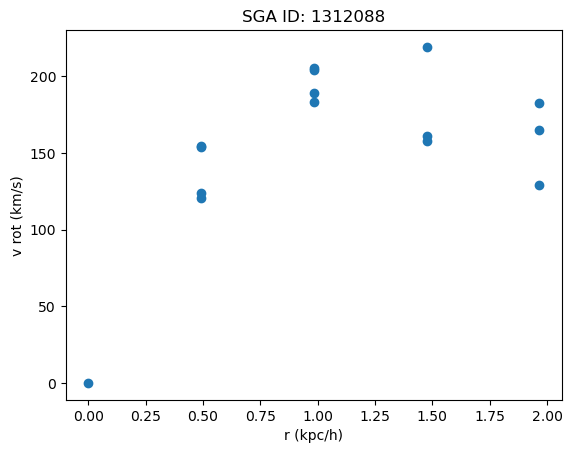

In [114]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 1312088
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    valid_fibers = targ_id[(targ_id['Velocity']<1000) & (targ_id['bad_map']==0)]

    if len(valid_fibers)==0:
        continue

    #r = valid_fibers['DIST_R26']
    r = valid_fibers['r_kpc']
    
    velocity = abs(valid_fibers['Velocity'])

    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(r, velocity)
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set(xlabel='r (kpc/h)', ylabel='v rot (km/s)')
    #ax.set_xlim(right=1.04)


In [115]:
def v_rot(r, v_max, r_turn, a):
    return (v_max * r)/((r_turn**a + r**a)**(1/a))

In [116]:
def chi2(params, v_data, v_err, r):
    v_max, r_turn, a = params
    v_model = (v_max * r)/((r_turn**a + r**a)**(1/a))
    return np.sum(((v_data-v_model)/v_err)**2)

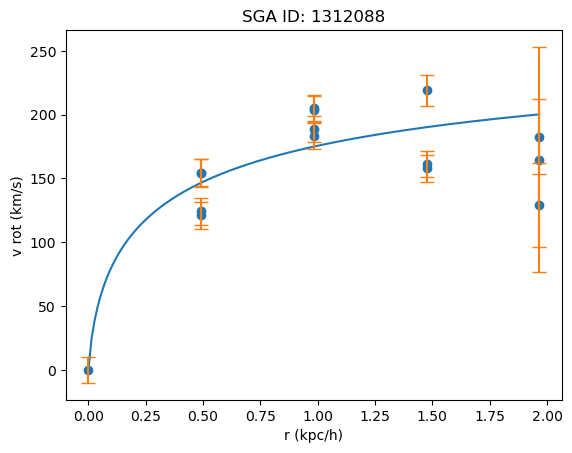

In [135]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 1312088
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    valid_fibers = targ_id[(targ_id['Velocity']<1000) & (targ_id['bad_map']==0)]

    if len(valid_fibers) < 3:
        continue

    r_kpc = valid_fibers['r_kpc']
    
    #absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    #create a pseudo-center fiber if there isn't one to assist with curve fitting
    if np.all(r_kpc) != 0:
        z_cen_err = valid_fibers['Z_center'][0]
        velocity = np.append(velocity,0)
        r_kpc = np.append(r_kpc,0)
        v_err = np.append(v_err,c*z_cen_err)

    #index for max velocity for initial guess
    idx = np.argmax(velocity)

    #bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,np.max(r_kpc)),(0,100)]

    #initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx], 1]

    #minimize fxn
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    
    vmax_fit, rturn_fit, alpha_fit = min_fxn.x
    #print(min_fxn)

    #hes = hessian(lambda x: chi2(x,velocity, v_err, r_kpc),[vmax_fit, rturn_fit, alpha_fit])


    # print(vmax_fit,rturn_fit,alpha_fit)
    # print(v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))

    r1 = np.linspace(0,np.max(r_kpc),len(r_kpc)*10)

    v_r = v_rot(r1,vmax_fit, rturn_fit, alpha_fit)

    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(r_kpc, velocity)
    ax.plot(r1,v_r)

    
    #ax.plot(r_kpc,v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))
    ax.errorbar(r_kpc, velocity, yerr = v_err, ls='none', capsize=5)
    
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set(xlabel='r (kpc/h)', ylabel='v rot (km/s)')

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 58.32465325486951
       x: [ 2.894e+02  8.109e-02  5.010e-01]
     nit: 10
   direc: [[-3.224e+01 -3.990e-01 -4.988e-02]
           [ 4.122e+00 -1.462e-03 -9.816e-04]
           [-7.626e+00 -2.108e-02 -1.410e-02]]
    nfev: 462
      V_err       
------------------
10.298161926674412
10.384004050235493
 10.43574827418646
 32.65766447223178
10.526319461583018
11.109785211141851
 10.39006842433978
10.458613207663717
 88.40743142872842
 10.26893004041665
10.537393553215532
29.341869682310378
10.421359304469132
12.124322447104483
10.770139193269992


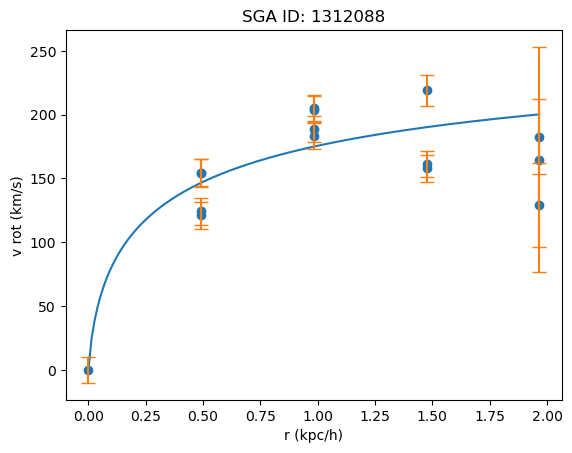

In [10]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 1312088
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    valid_fibers = targ_id[(targ_id['Velocity']<1000) & (targ_id['bad_map']==0)]

    if len(valid_fibers) < 3:
        continue

    #r = valid_fibers['DIST_R26']
    r_kpc = valid_fibers['r_kpc']
    
    #absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    #index for max velocity for initial guess
    idx = np.argmax(velocity)

    #bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,np.max(r_kpc)),(0,100)]

    #initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx], 1]

    #minimize fxn
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    
    vmax_fit, rturn_fit, alpha_fit = min_fxn.x
    print(min_fxn)

    # print(vmax_fit,rturn_fit,alpha_fit)
    # print(v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))

    r1 = np.linspace(0,np.max(r_kpc),len(r_kpc)*10)

    v_r = v_rot(r1,vmax_fit, rturn_fit, alpha_fit)

    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(r_kpc, velocity)
    ax.plot(r1,v_r)

    
    #ax.plot(r_kpc,v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))
    ax.errorbar(r_kpc, velocity, yerr = v_err, ls='none', capsize=5)
    print(v_err)
    
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set(xlabel='r (kpc/h)', ylabel='v rot (km/s)')

/tmp/ipykernel_505996/3517407738.py:3: RuntimeWarning: invalid value encountered in divide
  v_model = (v_max * r)/((r_turn**a + r**a)**(1/a))


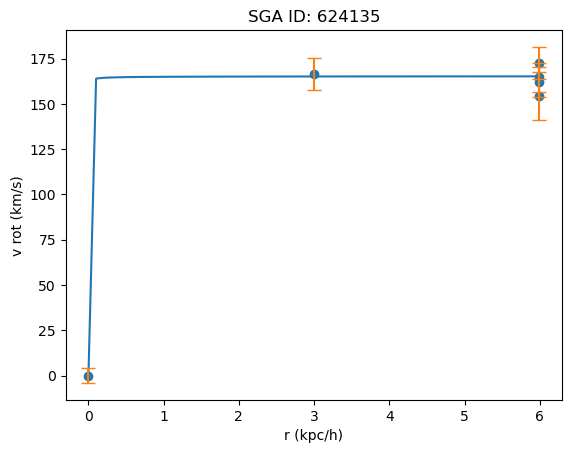

In [132]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 624135
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    valid_fibers = targ_id[(targ_id['Velocity']<1000) & (targ_id['bad_map']==0)]

    if len(valid_fibers) < 3:
        continue

    #r = valid_fibers['DIST_R26']
    r_kpc = valid_fibers['r_kpc']
    
    #absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']


    if np.all(r_kpc) != 0:
        z_cen_err = valid_fibers['Z_center'][0]
        velocity = np.append(velocity,0)
        r_kpc = np.append(r_kpc,0)
        v_err = np.append(v_err,c*z_cen_err)

    #index for max velocity for initial guess
    idx = np.argmax(velocity)

    #bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,np.max(r_kpc)),(0,100)]

    #initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx], 1]

    #minimize fxn
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    
    vmax_fit, rturn_fit, alpha_fit = min_fxn.x
    #print(min_fxn)

    # print(vmax_fit,rturn_fit,alpha_fit)
    # print(v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))

    r1 = np.linspace(0,np.max(r_kpc),len(r_kpc)*10)

    v_r = v_rot(r1,vmax_fit, rturn_fit, alpha_fit)

    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(r_kpc, velocity)
    ax.plot(r1,v_r)

    
    #ax.plot(r_kpc,v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))
    ax.errorbar(r_kpc, velocity, yerr = v_err, ls='none', capsize=5)
    #print(v_err)
    
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set(xlabel='r (kpc/h)', ylabel='v rot (km/s)')

/tmp/ipykernel_505996/3517407738.py:3: RuntimeWarning: invalid value encountered in divide
  v_model = (v_max * r)/((r_turn**a + r**a)**(1/a))


TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection,bad_fiber,ZERR_MOD,Velocity,V_err,Z_center,c_or_s,bad_map,r_kpc
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64,int64,float64,float64,float64,float64,int64,int64,float64
2403074870083585,183.47391750840885,14.859213422396255,0.0002388944435959267,3.446594270947237e-06,GALAXY,2851.9293732411497,0,TFT,790332,S,0.04600327566186039,0.4000000064713467,2,0,2.3608008396459846e-05,128.6091451338477,9.988602518565964,2.3511213479873237e-05,0,0,0.13753193879395173
2403080712749056,183.42831102527472,14.939977077502263,-0.0011778266001185767,1.589227446190622e-05,GALAXY,702.3923565765062,0,TFT,790332,S,0.046003275661699,0.4000000064699433,2,0,2.8221966138513433e-05,-296.1938590666281,11.012044749260097,2.3511213479873237e-05,0,0,0.13753193879346923
2407472916594691,183.48531379023325,14.839021101451742,0.00027605008883130035,1.5077311030299121e-05,GALAXY,130.13760155409727,0,EXT,790332,S,0.06900491250802311,0.6000000011444342,2,0,2.779972807637957e-05,139.7502443566412,10.91508909156819,2.3511213479873237e-05,0,0,0.20629790641059456
2407478759260162,183.4625190923866,14.87940518137824,0.00015607699749703674,4.084838537522991e-06,GALAXY,5993.814496498382,0,EXT,790332,S,0.023001637502564405,0.20000000038052193,2,0,2.3707691421211208e-05,103.77638073112253,10.009799430149743,2.3511213479873237e-05,0,0,0.06876596818254167
2407478759260165,183.43971585561178,14.919787009836512,-0.0008887279570362076,4.897350355043737e-06,GALAXY,3679.711367160271,0,EXT,790332,S,0.023001637502468836,0.20000000037969093,2,0,2.383723835173674e-05,-209.5077943423568,10.037412758443951,2.3511213479873237e-05,0,0,0.06876596818225596
2842879521193985,183.47391750840885,14.859213422396255,0.00024253105472637435,2.9352737604095982e-06,GALAXY,4657.382716322018,0,TFT,790332,S,0.04600327566186039,0.4000000064713467,2,0,2.3538879470610284e-05,129.69958092580038,9.97392885243171,2.3511213479873237e-05,0,0,0.13753193879395173
2842885363859456,183.42831102527472,14.939977077502263,-0.001169753150617244,2.0178250094474985e-05,GALAXY,387.7332444788062,0,TFT,790332,S,0.046003275661699,0.4000000064699433,2,0,3.0839675013825896e-05,-293.7730397969379,11.625852237773804,2.3511213479873237e-05,0,0,0.13753193879346923
2847277567705091,183.48531379023325,14.839021101451742,0.00022433911373783073,3.763250755141323e-05,GALAXY,15.624910966032076,0,EXT,790332,S,0.06900491250802311,0.6000000011444342,2,0,4.429050460562788e-05,124.24473770286666,15.032808622705772,2.3511213479873237e-05,0,0,0.20629790641059456
2847283410370560,183.45111854305125,14.899596377493316,-0.00019001797115553116,2.790305929578676e-06,GALAXY,80457.97701327517,0,TFT,790332,S,0.0,0.0,2,0,2.3511213479873237e-05,0.0,9.968062345359426,2.3511213479873237e-05,0,0,0.0


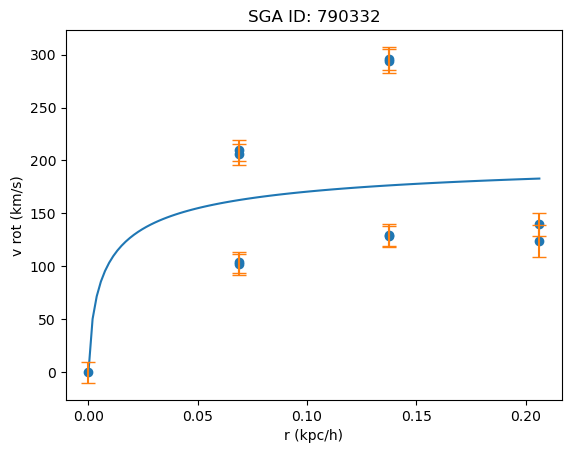

In [12]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 790332
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    valid_fibers = targ_id[(targ_id['Velocity']<1000) & (targ_id['bad_map']==0)]

    if len(valid_fibers) < 3:
        continue

    #r = valid_fibers['DIST_R26']
    r_kpc = valid_fibers['r_kpc']
    
    #absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    #index for max velocity for initial guess
    idx = np.argmax(velocity)

    #bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,np.max(r_kpc)),(0,10)]

    #initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx],1]

    #minimize fxn
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    
    vmax_fit, rturn_fit, alpha_fit = min_fxn.x

    #print(vmax_fit,rturn_fit,alpha_fit)
    # print(v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))
    #print(velocity)

    r1 = np.linspace(0,np.max(r_kpc),len(r_kpc)*10)
    v_r = v_rot(r1,vmax_fit, rturn_fit, alpha_fit)

    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(r_kpc, velocity)
    ax.plot(r1,v_r)

    
    #ax.plot(r_kpc,v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))

    ax.errorbar(r_kpc, velocity, yerr = v_err, ls='none', capsize=5)
    
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set(xlabel='r (kpc/h)', ylabel='v rot (km/s)')
valid_fibers

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection,bad_fiber,ZERR_MOD,Velocity,V_err,Z_center,c_or_s,bad_map,r_kpc
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64,int64,float64,float64,float64,float64,int64,int64,float64
2403098244939780,185.69920501863194,15.81730856404957,0.005233411271659658,5.271049574448798e-06,GALAXY,1210.5332055058097,0,TFT,7880,S,0.028761961967746108,0.399999996007282,2,0,2.4056265702334285e-05,-3.5209977977097364,7.738965812733952,9.363755163208958e-06,1,0,1.8314321605850414
2403098249134085,185.75792365333908,15.828146212260327,0.005335280298157383,1.5723380010297554e-05,GALAXY,358.62099460565514,0,TFT,7880,S,0.028761961967761394,0.3999999960074946,2,0,2.8253429872010565e-05,26.85921720987236,8.923226753970987,9.363755163208958e-06,1,0,1.8314321605860149
2407496295645188,185.74324340450644,15.825438280268983,0.005227759731996915,6.5305132124882345e-06,GALAXY,1802.7238841954313,0,EXT,7880,S,0.01438098098387043,0.1999999980036045,2,0,2.4363114827300124e-05,-5.206446220854481,7.824762767879777,9.363755163208958e-06,1,0,0.9157160771929862
2407496295645191,185.71388408709106,15.820019455959304,0.005135495122947853,2.2327037543628643e-06,GALAXY,9416.193258767496,0,EXT,7880,S,0.014380980983892198,0.19999999800390722,2,0,2.357536003900183e-05,-32.72235323268438,7.604792870707282,9.363755163208958e-06,1,0,0.9157160771943722
2842902896050180,185.69920501863194,15.81730856404957,0.005230050016684623,4.741504514994076e-06,GALAXY,1598.728181013139,0,TFT,7880,S,0.028761961967746108,0.399999996007282,2,0,2.3945733162995082e-05,-4.523418772458085,7.7080952168015076,9.363755163208958e-06,1,0,1.8314321605850414
2842902900244485,185.75792365333908,15.828146212260327,0.005353713346464679,1.2872034680364344e-05,GALAXY,483.5602062536,0,TFT,7880,S,0.028761961967761394,0.3999999960074946,2,0,2.677202092034428e-05,32.356471773598926,8.502808671494195,9.363755163208958e-06,1,0,1.8314321605860149
2847300942561283,185.68452634375404,15.81459668590905,0.004659460116051287,6.868848147733363e-05,GALAXY,18.4168526289277,0,EXT,7880,S,0.04314294295163617,0.5999999940111596,2,0,7.258373449531523e-05,-174.6894099313618,21.940381084496053,9.363755163208958e-06,1,0,2.747148256375482
2847300946755589,185.77260429550574,15.830853157203695,0.0055126256443209206,5.2772489341127876e-05,GALAXY,53.968969027351704,0,EXT,7880,S,0.04314294295165878,0.599999994011474,2,0,5.7759515904774644e-05,79.74859813619052,17.54193649135835,9.363755163208958e-06,1,0,2.747148256376922
2847300946755591,185.71388408709106,15.820019455959304,0.005140447033667482,2.0871302431289116e-06,GALAXY,9366.455497487143,0,EXT,7880,S,0.014380980983892198,0.19999999800390722,2,0,2.356213434426501e-05,-31.24555388030404,7.601108068021714,9.363755163208958e-06,1,0,0.9157160771943722


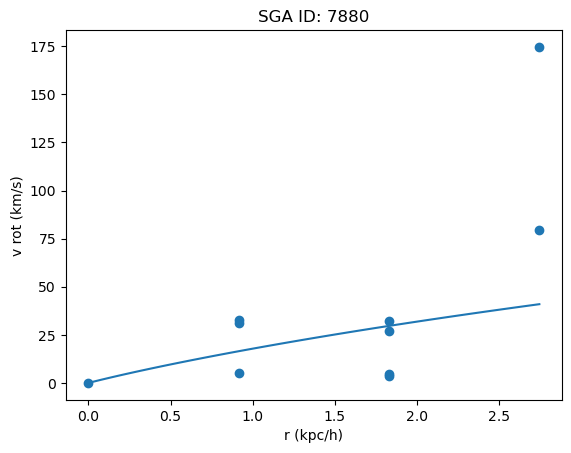

In [136]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 7880
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    valid_fibers = targ_id[(targ_id['Velocity']<1000) & (targ_id['bad_map']==0)]

    if len(valid_fibers) < 3:
        continue

    #r = valid_fibers['DIST_R26']
    r_kpc = valid_fibers['r_kpc']
    
    #absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    if np.all(r_kpc) != 0:
        z_cen_err = valid_fibers['Z_center'][0]
        velocity = np.append(velocity,0)
        r_kpc = np.append(r_kpc,0)
        v_err = np.append(v_err,c*z_cen_err)

    #index for max velocity for initial guess
    idx = np.argmax(velocity)

    #bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,50),(0.5,1)]

    #initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx], 1]

    #minimize fxn
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    
    vmax_fit, rturn_fit, alpha_fit = min_fxn.x

    # print(vmax_fit,rturn_fit,alpha_fit)
    # print(v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))

    r1 = np.linspace(0,np.max(r_kpc),len(r_kpc)*10)
    v_r = v_rot(r1,vmax_fit, rturn_fit, alpha_fit)

    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(r_kpc, velocity)
    ax.plot(r1,v_r)

    
    #ax.plot(r_kpc,v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))
    #ax.errorbar(r, velocity, yerr = v_err)
    
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set(xlabel='r (kpc/h)', ylabel='v rot (km/s)')

valid_fibers

## Test

In [16]:
np.random.normal(12,1,100)

array([11.70605516, 13.12504286, 10.82020394, 11.55624363, 12.6928857 ,
       12.7732236 , 11.34034332, 10.6560521 , 12.80813225, 13.05460124,
       11.41110187, 12.26074744, 12.67891622, 11.8718471 , 13.89217614,
       10.55702827, 10.65330571, 12.13147471, 12.83281754, 11.21369615,
       11.22056508, 13.61557564, 12.00838733, 12.76119734, 11.77754707,
       10.74666443, 10.596049  , 12.64227657, 11.00158981, 12.5392513 ,
       12.5946139 , 11.19925247, 12.11970574, 11.18803084, 12.3158529 ,
       11.25647539, 11.6463561 , 13.01180125, 13.86239525, 10.50179635,
       12.41306818, 12.86011862, 12.33099346, 13.11685228, 12.84368621,
       13.7780965 , 13.41302314, 11.92990776, 11.53502251, 11.53582335,
       11.04961803, 11.87683974, 12.64747513, 11.56460455, 11.13322446,
       11.93657379, 13.56097222, 10.33621094, 12.22114029, 11.48953503,
       12.3586228 , 10.97680458, 12.6557919 , 10.36606393, 12.32184127,
       11.66532789, 10.65724475, 11.5274505 , 13.56166628, 13.78